In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv(r"C:\Users\Sourabh\Documents\Zomato_Project\Raw_dataset\zomato.csv")

In [9]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [10]:
df.tail()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield
51716,https://www.zomato.com/bangalore/the-nest-the-...,"ITPL Main Road, KIADB Export Promotion Industr...",The Nest - The Den Bengaluru,No,No,3.4 /5,13,+91 8071117272,"ITPL Main Road, Whitefield","Bar, Casual Dining",NaN,"Finger Food, North Indian, Continental","1,500","[('Rated 5.0', 'RATED\n Great ambience , look...",[],Pubs and bars,Whitefield


In [11]:
df.sample(5, random_state=42)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
8440,https://www.zomato.com/bangalore/kalingas-btm?...,"399, 16th Main, N.S Palya, BTM, Bangalore",Kalingas,Yes,No,3.9/5,179,080 42038180,BTM,Quick Bites,"Rasgulla, Mutton Kosha, Chicken Kasha, Samosa ...","Oriya, Fast Food",250,"[('Rated 3.0', 'RATED\n A pocket friendly foo...",[],Delivery,BTM
23575,https://www.zomato.com/bangalore/angel-restaur...,"1st Cross, Bilekahalli, Near IIMB College, Ban...",Angel Restaurant,Yes,No,2.8/5,165,+91 9035699847\r\n+91 9880714970,Bannerghatta Road,Quick Bites,NaN,"Kerala, South Indian, North Indian",450,"[('Rated 1.0', 'RATED\n I cannot say a word a...","['Kappa', 'Kappa Biryani', 'Chicken Biryani', ...",Dine-out,JP Nagar
16711,https://www.zomato.com/bangalore/cafe-talkhous...,"4rd floor, 7th Cross, Opposite to BMTC Bus Dep...",Cafe Talkhouse,No,No,3.8/5,23,NaN,HSR,Quick Bites,NaN,North Indian,NaN,"[('Rated 5.0', 'RATED\n Have been to this pla...",[],Delivery,HSR
42588,https://www.zomato.com/bangalore/paratha-xpres...,"17/1 Cambridge Road, Opposite The Frank Antony...",Paratha Xpress,No,No,3.5 /5,8,065535 07908402366,Ulsoor,Quick Bites,NaN,"North Indian, Chinese",200,"[('Rated 5.0', 'RATED\n good job!'), ('Rated ...",[],Delivery,MG Road
5266,https://www.zomato.com/bangalore/classic-lassi...,"Skywalk, 5/1, Near Body Craft, Assaye Road, Ul...",Classic Lassi Shop,Yes,No,3.5/5,43,+91 8792958786\r\r\n+91 8073579529,Ulsoor,Beverage Shop,NaN,"Beverages, Ice Cream",150,"[('Rated 3.0', 'RATED\n I have mixed feeling ...","['Fruit Salad with Ice Cream', 'Brownie with I...",Delivery,Brigade Road


In [12]:
df.shape

(51717, 17)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [14]:
df.dtypes

url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object

In [15]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [16]:
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_values.sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage
dish_liked,28078,54.29
rate,7775,15.03
phone,1208,2.34
approx_cost(for two people),346,0.67
rest_type,227,0.44
cuisines,45,0.09
location,21,0.04
url,0,0.00
address,0,0.00
votes,0,0.00


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.nunique()

url                            51717
address                        11495
name                            8792
online_order                       2
book_table                         2
rate                              64
votes                           2328
phone                          14926
location                          93
rest_type                         93
dish_liked                      5271
cuisines                        2723
approx_cost(for two people)       70
reviews_list                   22513
menu_item                       9098
listed_in(type)                    7
listed_in(city)                   30
dtype: int64

In [19]:
df.nunique()

url                            51717
address                        11495
name                            8792
online_order                       2
book_table                         2
rate                              64
votes                           2328
phone                          14926
location                          93
rest_type                         93
dish_liked                      5271
cuisines                        2723
approx_cost(for two people)       70
reviews_list                   22513
menu_item                       9098
listed_in(type)                    7
listed_in(city)                   30
dtype: int64

In [20]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [21]:
df.describe(include='object')

,url,address,name,online_order,book_table,rate,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
count,51717,51717,51717,51717,51717,43942,50509,51696,51490,23639,51672,51371,51717,51717,51717,51717
unique,51717,11495,8792,2,2,64,14926,93,93,5271,2723,70,22513,9098,7,30
top,https://www.zomato.com/bangalore/jalsa-banasha...,Delivery Only,Cafe Coffee Day,Yes,No,NEW,080 43334321,BTM,Quick Bites,Biryani,North Indian,300,[],[],Delivery,BTM
freq,1,128,96,30444,45268,2208,216,5124,19132,182,2913,7576,7595,39617,25942,3279


In [22]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [23]:
for col in df.columns:
    print(col)

url
address
name
online_order
book_table
rate
votes
phone
location
rest_type
dish_liked
cuisines
approx_cost(for two people)
reviews_list
menu_item
listed_in(type)
listed_in(city)


In [24]:
df.dtypes

url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object

In [25]:
quality_report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

quality_report

,Data Type,Missing Values,Unique Values
url,object,0,51717
address,object,0,11495
name,object,0,8792
online_order,object,0,2
book_table,object,0,2
rate,object,7775,64
votes,int64,0,2328
phone,object,1208,14926
location,object,21,93
rest_type,object,227,93


In [27]:
df_clean = df.copy()

In [28]:
df_clean.rename(columns={
    'approx_cost(for two people)': 'approx_cost',
    'listed_in(type)': 'restaurant_type',
    'listed_in(city)': 'city'
}, inplace=True)

In [29]:
df_clean.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost', 'reviews_list', 'menu_item', 'restaurant_type', 'city'],
      dtype='object')

In [30]:
df_clean.drop(columns=['url', 'phone', 'address'], inplace=True)

In [31]:
df_clean.shape

(51717, 14)

In [32]:
df_clean.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,reviews_list,menu_item,restaurant_type,city
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [33]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             51717 non-null  object
 1   online_order     51717 non-null  object
 2   book_table       51717 non-null  object
 3   rate             43942 non-null  object
 4   votes            51717 non-null  int64 
 5   location         51696 non-null  object
 6   rest_type        51490 non-null  object
 7   dish_liked       23639 non-null  object
 8   cuisines         51672 non-null  object
 9   approx_cost      51371 non-null  object
 10  reviews_list     51717 non-null  object
 11  menu_item        51717 non-null  object
 12  restaurant_type  51717 non-null  object
 13  city             51717 non-null  object
dtypes: int64(1), object(13)
memory usage: 5.5+ MB


In [34]:
df_clean.isnull().sum()

name                   0
online_order           0
book_table             0
rate                7775
votes                  0
location              21
rest_type            227
dish_liked         28078
cuisines              45
approx_cost          346
reviews_list           0
menu_item              0
restaurant_type        0
city                   0
dtype: int64

In [35]:
df_clean['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [36]:
df_clean['rate'].value_counts(dropna=False)

rate
NaN       7775
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
          ... 
2.2 /5       7
2.0 /5       7
2.0/5        4
1.8 /5       3
1.8/5        2
Name: count, Length: 65, dtype: int64

In [37]:
import numpy as np

df_clean['rate'] = df_clean['rate'].replace(['NEW', '-'], np.nan)

In [38]:
df_clean['rate'].value_counts(dropna=False)

rate
NaN       10052
3.9/5      2098
3.8/5      2022
3.7/5      2011
3.9 /5     1874
          ...  
2.2 /5        7
2.0 /5        7
2.0/5         4
1.8 /5        3
1.8/5         2
Name: count, Length: 63, dtype: int64

In [39]:
df_clean['rate'] = df_clean['rate'].str.replace('/5', '', regex=False)

In [40]:
df_clean['rate'].unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', nan, '2.9', '3.5', '2.6',
       '3.8 ', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2', '2.3',
       '3.4 ', '3.6 ', '4.8', '3.9 ', '4.2 ', '4.0 ', '4.1 ', '3.7 ',
       '3.1 ', '2.9 ', '3.3 ', '2.8 ', '3.5 ', '2.7 ', '2.5 ', '3.2 ',
       '2.6 ', '4.5 ', '4.3 ', '4.4 ', '4.9', '2.1', '2.0', '1.8', '4.6 ',
       '4.9 ', '3.0 ', '4.8 ', '2.3 ', '4.7 ', '2.4 ', '2.1 ', '2.2 ',
       '2.0 ', '1.8 '], dtype=object)

In [41]:
df_clean['rate'] = pd.to_numeric(df_clean['rate'])

In [42]:
df_clean['rate'].dtype

dtype('float64')

In [43]:
df_clean['rate'].isnull().sum()

np.int64(10052)

In [44]:
median_rating = df_clean['rate'].median()

df_clean['rate'].fillna(median_rating, inplace=True)

In [45]:
print(df_clean['rate'].dtype)

print(df_clean['rate'].isnull().sum())

df_clean['rate'].describe()

float64
0


count    51717.000000
mean         3.700362
std          0.395391
min          1.800000
25%          3.500000
50%          3.700000
75%          3.900000
max          4.900000
Name: rate, dtype: float64

In [46]:
df_clean['approx_cost'].dtype

dtype('O')

In [47]:
df_clean['approx_cost'].unique()[:20]

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000'], dtype=object)

In [48]:
df_clean['approx_cost'] = df_clean['approx_cost'].str.replace(',', '', regex=False)

In [49]:
df_clean['approx_cost'] = pd.to_numeric(df_clean['approx_cost'])

In [50]:
df_clean['approx_cost'].isnull().sum()

np.int64(346)

In [51]:
median_cost = df_clean['approx_cost'].median()

df_clean['approx_cost'].fillna(median_cost, inplace=True)

In [52]:
df_clean['approx_cost'].describe()

count    51717.000000
mean       554.391689
std        437.563723
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost, dtype: float64

In [53]:
df_clean.isnull().sum()

name                   0
online_order           0
book_table             0
rate                   0
votes                  0
location              21
rest_type            227
dish_liked         28078
cuisines              45
approx_cost            0
reviews_list           0
menu_item              0
restaurant_type        0
city                   0
dtype: int64

In [54]:
df_clean['location'].fillna(df_clean['location'].mode()[0], inplace=True)

In [55]:
df_clean['rest_type'].fillna(df_clean['rest_type'].mode()[0], inplace=True)

In [56]:
df_clean['cuisines'].fillna(df_clean['cuisines'].mode()[0], inplace=True)

In [57]:
df_clean['dish_liked'].fillna('Not Mentioned', inplace=True)

In [58]:
df_clean.isnull().sum()

name               0
online_order       0
book_table         0
rate               0
votes              0
location           0
rest_type          0
dish_liked         0
cuisines           0
approx_cost        0
reviews_list       0
menu_item          0
restaurant_type    0
city               0
dtype: int64

In [59]:
df_clean['online_order'].value_counts()

online_order
Yes    30444
No     21273
Name: count, dtype: int64

In [60]:
df_clean['book_table'].value_counts()

book_table
No     45268
Yes     6449
Name: count, dtype: int64

In [61]:
df_clean['restaurant_type'].value_counts().head(15)

restaurant_type
Delivery              25942
Dine-out              17779
Desserts               3593
Cafes                  1723
Drinks & nightlife     1101
Buffet                  882
Pubs and bars           697
Name: count, dtype: int64

In [62]:
df_clean['city'].value_counts()

city
BTM                      3279
Koramangala 7th Block    2938
Koramangala 5th Block    2836
Koramangala 4th Block    2779
Koramangala 6th Block    2623
Jayanagar                2371
JP Nagar                 2096
Indiranagar              1860
Church Street            1827
MG Road                  1811
Brigade Road             1769
Lavelle Road             1744
HSR                      1741
Marathahalli             1659
Residency Road           1620
Whitefield               1620
Bannerghatta Road        1617
Brookefield              1518
Old Airport Road         1425
Kammanahalli             1329
Kalyan Nagar             1309
Basavanagudi             1266
Sarjapur Road            1261
Electronic City          1229
Bellandur                1227
Frazer Town              1185
Malleshwaram             1096
Rajajinagar              1079
Banashankari              863
New BEL Road              740
Name: count, dtype: int64

In [63]:
df_clean.rename(columns={'city': 'area'}, inplace=True)

In [64]:
df_clean.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost', 'reviews_list',
       'menu_item', 'restaurant_type', 'area'],
      dtype='object')

In [65]:
df_clean.rename(columns={
    'name': 'restaurant_name',
    'book_table': 'table_booking',
    'rate': 'rating',
    'rest_type': 'restaurant_category',
    'dish_liked': 'popular_dishes',
    'approx_cost': 'cost_for_two',
    'reviews_list': 'reviews',
    'menu_item': 'menu_items',
    'restaurant_type': 'listing_type',
    'area': 'area'
}, inplace=True)

In [66]:
df_clean.columns

Index(['restaurant_name', 'online_order', 'table_booking', 'rating', 'votes',
       'location', 'restaurant_category', 'popular_dishes', 'cuisines',
       'cost_for_two', 'reviews', 'menu_items', 'listing_type', 'area'],
      dtype='object')

In [67]:
df_clean.isnull().sum()

restaurant_name        0
online_order           0
table_booking          0
rating                 0
votes                  0
location               0
restaurant_category    0
popular_dishes         0
cuisines               0
cost_for_two           0
reviews                0
menu_items             0
listing_type           0
area                   0
dtype: int64

In [68]:
df_clean['online_order'].value_counts()

online_order
Yes    30444
No     21273
Name: count, dtype: int64

In [69]:
df_clean['table_booking'].value_counts()

table_booking
No     45268
Yes     6449
Name: count, dtype: int64

In [70]:
df_clean['restaurant_category'].value_counts().head(20)

restaurant_category
Quick Bites                   19359
Casual Dining                 10330
Cafe                           3732
Delivery                       2604
Dessert Parlor                 2263
Takeaway, Delivery             2037
Casual Dining, Bar             1154
Bakery                         1141
Beverage Shop                   867
Bar                             697
Food Court                      624
Sweet Shop                      468
Bar, Casual Dining              425
Lounge                          396
Pub                             357
Fine Dining                     346
Casual Dining, Cafe             319
Beverage Shop, Quick Bites      298
Bakery, Quick Bites             289
Mess                            267
Name: count, dtype: int64

In [71]:
df_clean['listing_type'].value_counts()

listing_type
Delivery              25942
Dine-out              17779
Desserts               3593
Cafes                  1723
Drinks & nightlife     1101
Buffet                  882
Pubs and bars           697
Name: count, dtype: int64

In [72]:
df_clean['area'].value_counts()

area
BTM                      3279
Koramangala 7th Block    2938
Koramangala 5th Block    2836
Koramangala 4th Block    2779
Koramangala 6th Block    2623
Jayanagar                2371
JP Nagar                 2096
Indiranagar              1860
Church Street            1827
MG Road                  1811
Brigade Road             1769
Lavelle Road             1744
HSR                      1741
Marathahalli             1659
Residency Road           1620
Whitefield               1620
Bannerghatta Road        1617
Brookefield              1518
Old Airport Road         1425
Kammanahalli             1329
Kalyan Nagar             1309
Basavanagudi             1266
Sarjapur Road            1261
Electronic City          1229
Bellandur                1227
Frazer Town              1185
Malleshwaram             1096
Rajajinagar              1079
Banashankari              863
New BEL Road              740
Name: count, dtype: int64

In [73]:
df_clean['cuisines'].value_counts().head(20)

cuisines
North Indian                           2958
North Indian, Chinese                  2385
South Indian                           1828
Biryani                                 918
Bakery, Desserts                        911
Fast Food                               803
Desserts                                766
Cafe                                    756
South Indian, North Indian, Chinese     726
Bakery                                  651
Chinese                                 556
Ice Cream, Desserts                     417
Chinese, North Indian                   415
Mithai, Street Food                     372
Desserts, Ice Cream                     354
North Indian, Chinese, Biryani          352
South Indian, North Indian              343
North Indian, South Indian              343
North Indian, South Indian, Chinese     305
Beverages                               301
Name: count, dtype: int64

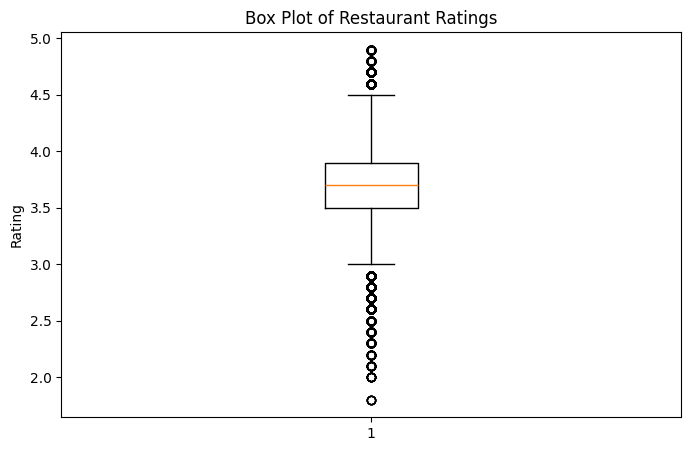

In [74]:
plt.figure(figsize=(8,5))

plt.boxplot(df_clean['rating'])

plt.title("Box Plot of Restaurant Ratings")

plt.ylabel("Rating")

plt.show()

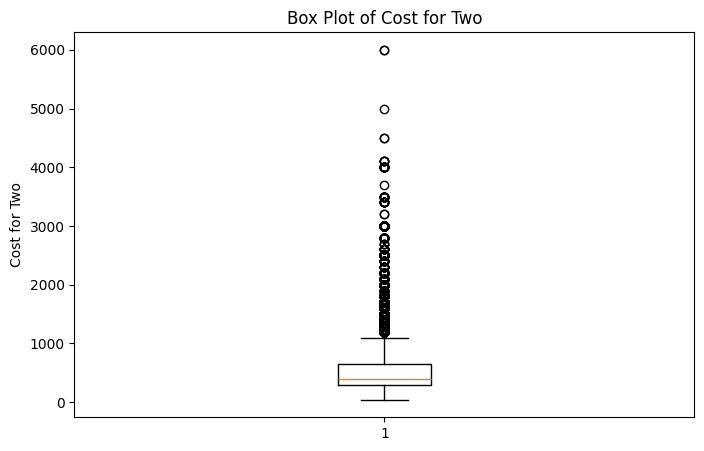

In [75]:
plt.figure(figsize=(8,5))

plt.boxplot(df_clean['cost_for_two'])

plt.title("Box Plot of Cost for Two")

plt.ylabel("Cost for Two")

plt.show()

In [76]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   restaurant_name      51717 non-null  object 
 1   online_order         51717 non-null  object 
 2   table_booking        51717 non-null  object 
 3   rating               51717 non-null  float64
 4   votes                51717 non-null  int64  
 5   location             51717 non-null  object 
 6   restaurant_category  51717 non-null  object 
 7   popular_dishes       51717 non-null  object 
 8   cuisines             51717 non-null  object 
 9   cost_for_two         51717 non-null  float64
 10  reviews              51717 non-null  object 
 11  menu_items           51717 non-null  object 
 12  listing_type         51717 non-null  object 
 13  area                 51717 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 5.5+ MB


In [77]:
df_clean.to_csv(
    r"C:\Users\Sourabh\Documents\Zomato_Project\Clean_Data\zomato_cleaned.csv",
    index=False
)

In [78]:
import os

os.path.exists(
    r"C:\Users\Sourabh\Documents\Zomato_Project\Clean_Data\zomato_cleaned.csv"
)

True

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 11

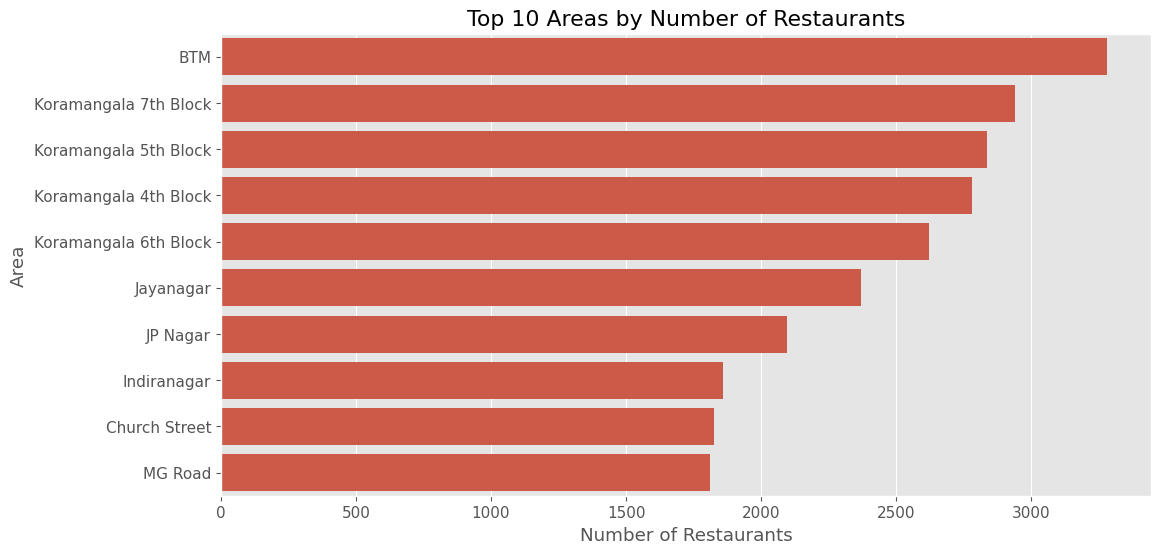

In [81]:
#Which areas of Bengaluru have the highest number of restaurants?
area_count = (
    df_clean['area']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=area_count.values,
    y=area_count.index
)

plt.title('Top 10 Areas by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('Area')

plt.show()
#The chart identifies restaurant hotspots in Bengaluru. Areas with the highest number of restaurants indicate strong commercial activity and higher customer demand.

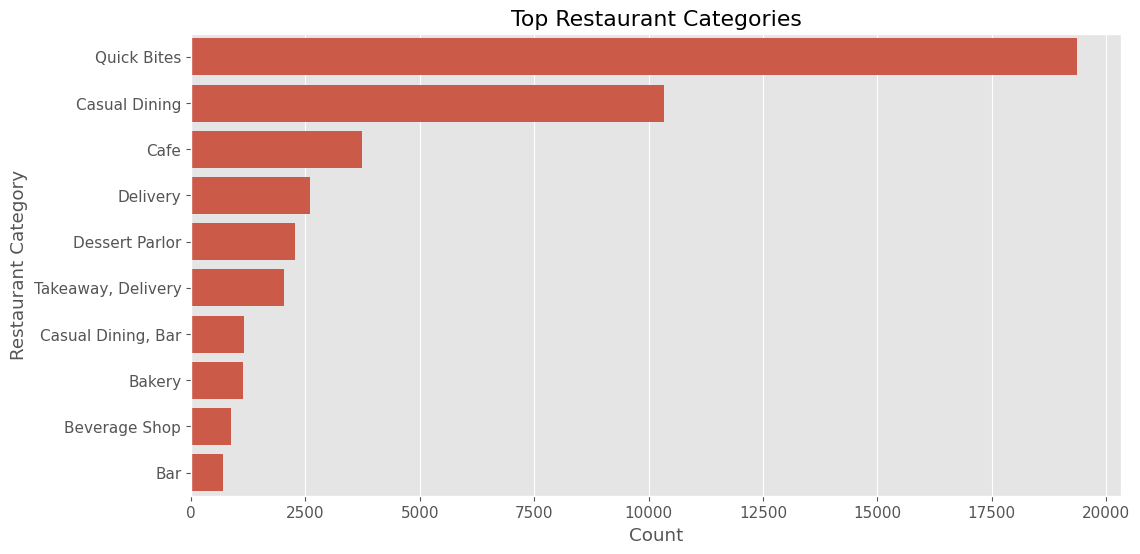

In [82]:
#Which restaurant categories are most common?
category_count = (
    df_clean['restaurant_category']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_count.values,
    y=category_count.index
)

plt.title('Top Restaurant Categories')
plt.xlabel('Count')
plt.ylabel('Restaurant Category')

plt.show()
#Quick Bites and Casual Dining generally dominate the Bengaluru restaurant market.

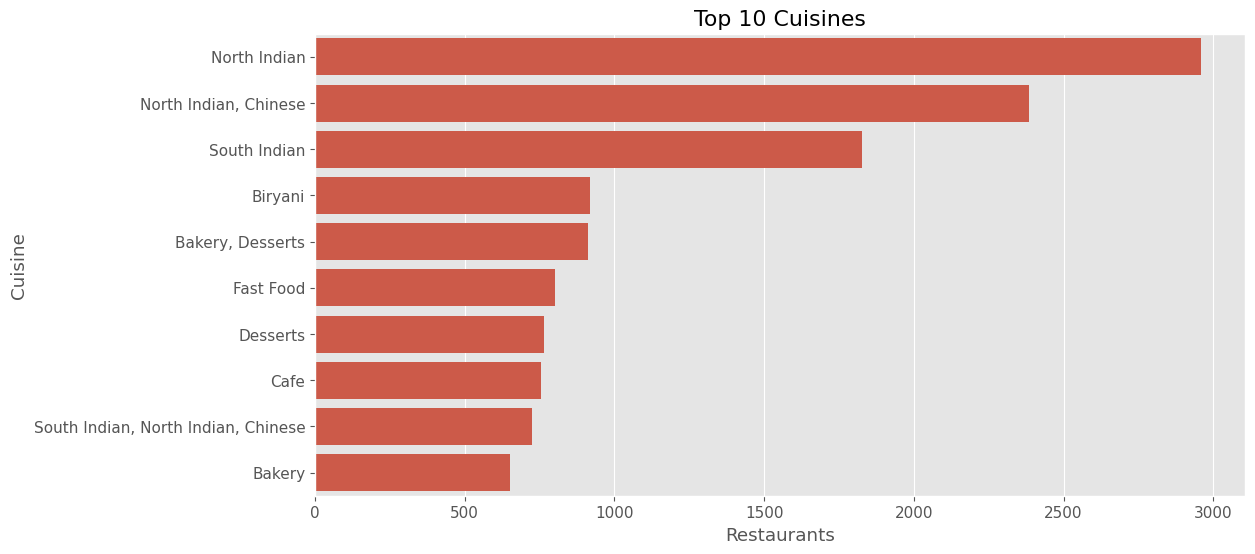

In [83]:
#This reveals customer cuisine preferences and helps identify high-demand food categories.
cuisine_count = (
    df_clean['cuisines']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=cuisine_count.values,
    y=cuisine_count.index
)

plt.title('Top 10 Cuisines')

plt.xlabel('Restaurants')

plt.ylabel('Cuisine')

plt.show()

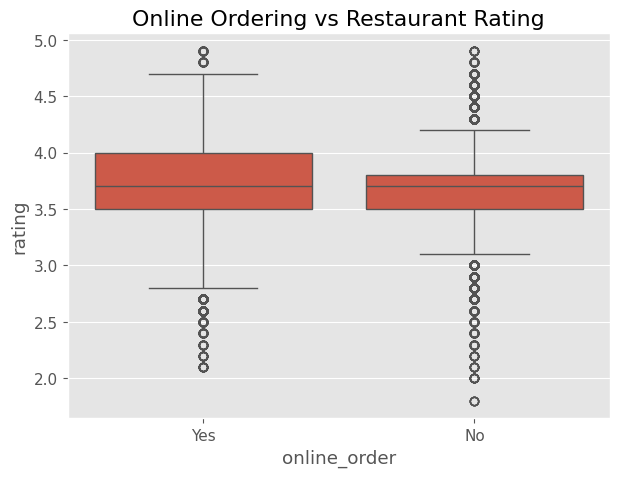

In [84]:
#Online Ordering vs Rating
plt.figure(figsize=(7,5))

sns.boxplot(
    x='online_order',
    y='rating',
    data=df_clean
)

plt.title('Online Ordering vs Restaurant Rating')

plt.show()
#Business Insight

#Restaurants offering online ordering may show different rating patterns compared to those without this service.

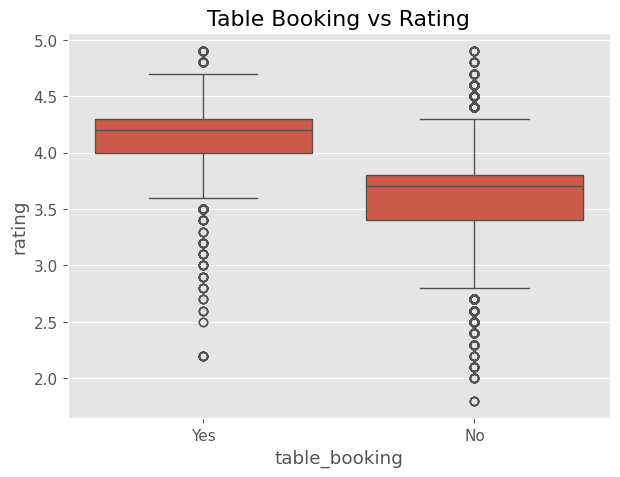

In [85]:
#Table Booking vs Rating
plt.figure(figsize=(7,5))

sns.boxplot(
    x='table_booking',
    y='rating',
    data=df_clean
)

plt.title('Table Booking vs Rating')

plt.show()
#Restaurants with table booking often target dine-in customers and may receive higher ratings.

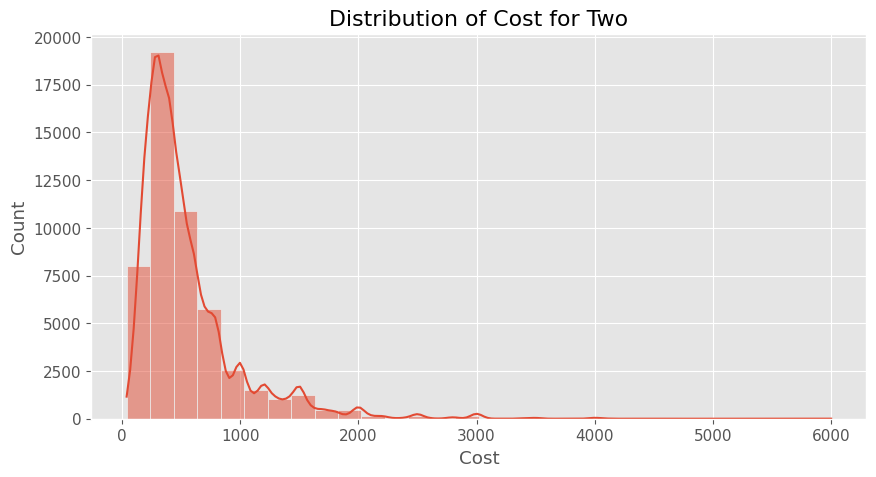

In [86]:
#Cost for Two Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df_clean['cost_for_two'],
    bins=30,
    kde=True
)

plt.title('Distribution of Cost for Two')

plt.xlabel('Cost')

plt.show()
#This shows whether most restaurants are budget-friendly or premium.

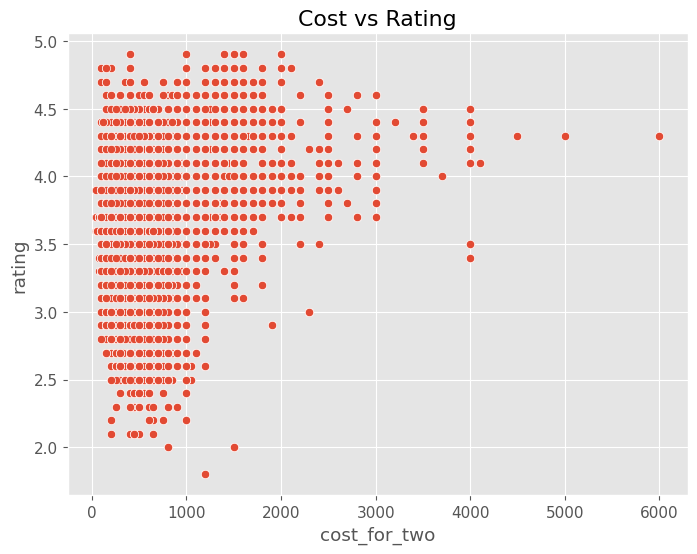

In [87]:
#Cost vs Rating
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='cost_for_two',
    y='rating',
    data=df_clean
)

plt.title('Cost vs Rating')

plt.show()
#Determine whether higher-priced restaurants consistently receive better ratings.

In [88]:
#Top 10 Highest Rated Restaurants
top_rating = (
    df_clean
    .sort_values('rating', ascending=False)
    [['restaurant_name','rating']]
    .drop_duplicates()
    .head(10)
)

top_rating


,restaurant_name,rating
9099,Asia Kitchen By Mainland China,4.9
37843,Belgian Waffle Factory,4.9
39559,Punjab Grill,4.9
6746,Flechazo,4.9
19393,AB's - Absolute Barbecues,4.9
4944,Byg Brewski Brewing Company,4.9
18496,Milano Ice Cream,4.9
45812,SantÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃ...,4.9
45544,The Pizza Bakery,4.8
36577,Biergarten,4.8


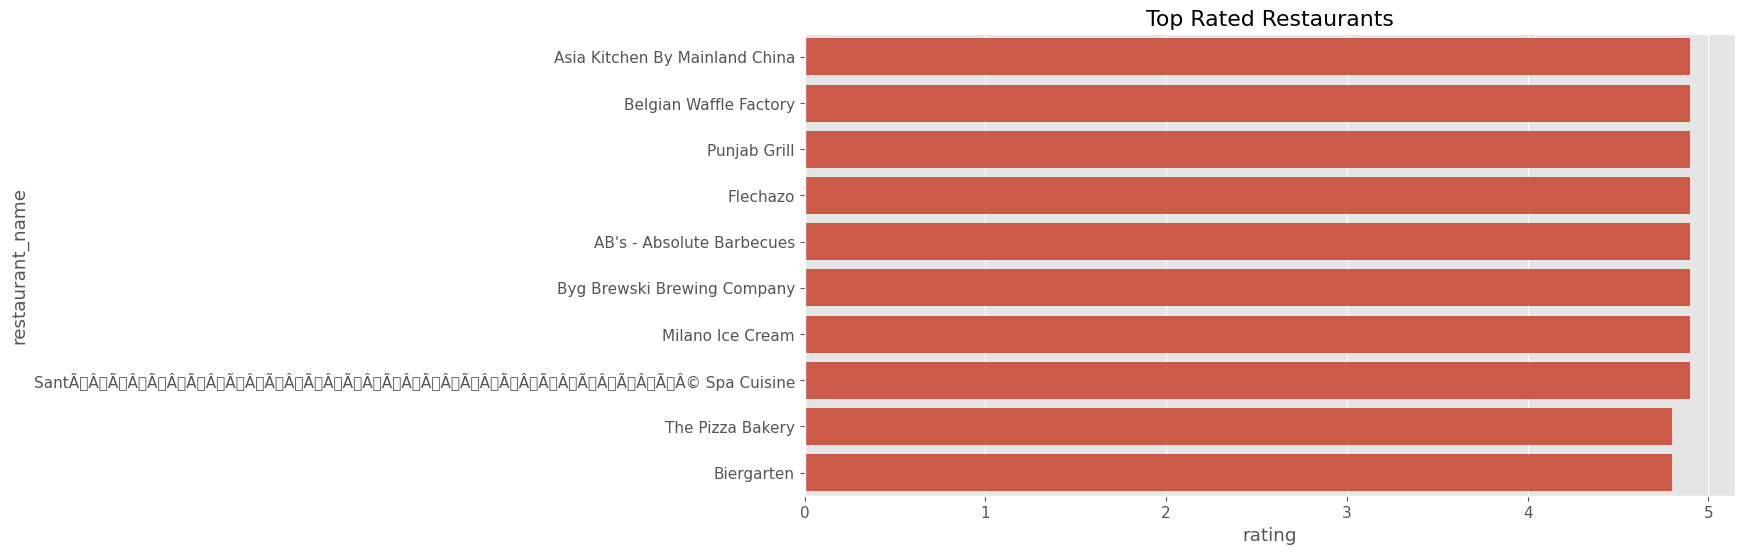

In [89]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rating,
    x='rating',
    y='restaurant_name'
)

plt.title('Top Rated Restaurants')

plt.show()

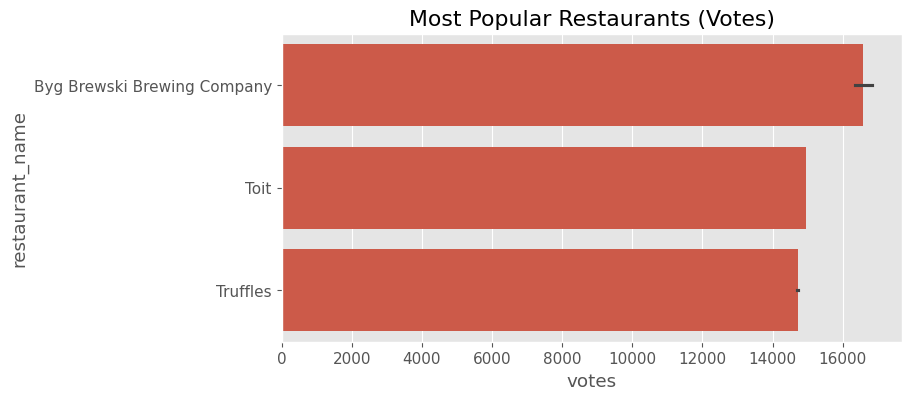

In [91]:
#Top 10 Most Voted Restaurants
top_votes = (
    df_clean
    .sort_values('votes', ascending=False)
    [['restaurant_name','votes']]
    .drop_duplicates()
    .head(10)
)

plt.figure(figsize=(8,4))

sns.barplot(
    data=top_votes,
    x='votes',
    y='restaurant_name'
)

plt.title('Most Popular Restaurants (Votes)')

plt.show()

In [95]:
print(top_votes.shape)
print(top_votes)

(10, 2)
                   restaurant_name  votes
49627  Byg Brewski Brewing Company  16832
4944   Byg Brewski Brewing Company  16345
18643                         Toit  14956
36668                     Truffles  14726
34779                     Truffles  14723
32152                     Truffles  14717
29303                     Truffles  14710
28384                     Truffles  14704
27806                     Truffles  14694
26549                     Truffles  14690


In [96]:
top_votes = (
    df_clean.groupby('restaurant_name', as_index=False)['votes']
    .max()
    .sort_values(by='votes', ascending=False)
    .head(10)
)

top_votes

,restaurant_name,votes
1274,Byg Brewski Brewing Company,16832
8231,Toit,14956
8269,Truffles,14726
129,AB's - Absolute Barbecues,12121
7751,The Black Pearl,10550
978,Big Pitcher,9300
5549,Onesta,9085
548,Arbor Brewing Company,8419
2446,Empire Restaurant,8304
5907,Prost Brew Pub,7871


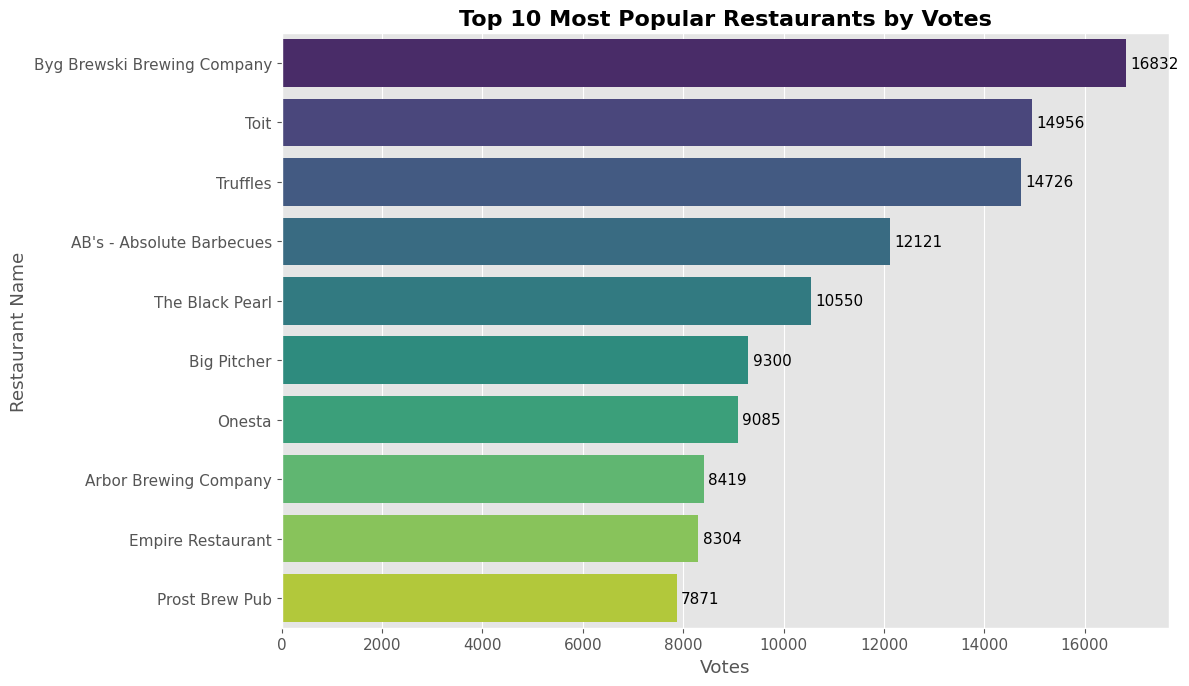

In [102]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_votes,
    x='votes',
    y='restaurant_name',
    palette='viridis'
)

# Add vote labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%d', padding=3)

plt.title('Top 10 Most Popular Restaurants by Votes', fontsize=16, fontweight='bold')
plt.xlabel('Votes')
plt.ylabel('Restaurant Name')

plt.tight_layout()
plt.show()

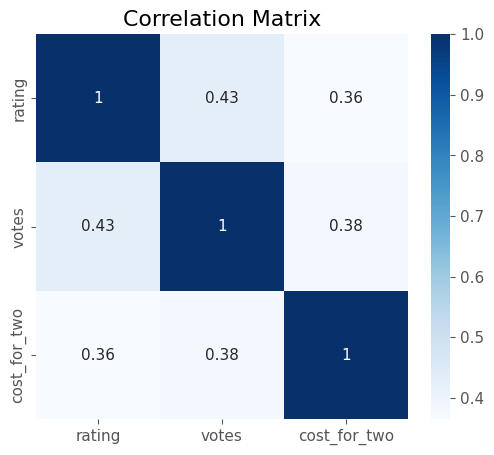

In [98]:
#Correlation Analysis
corr = df_clean[
    ['rating','votes','cost_for_two']
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Matrix')

plt.show()

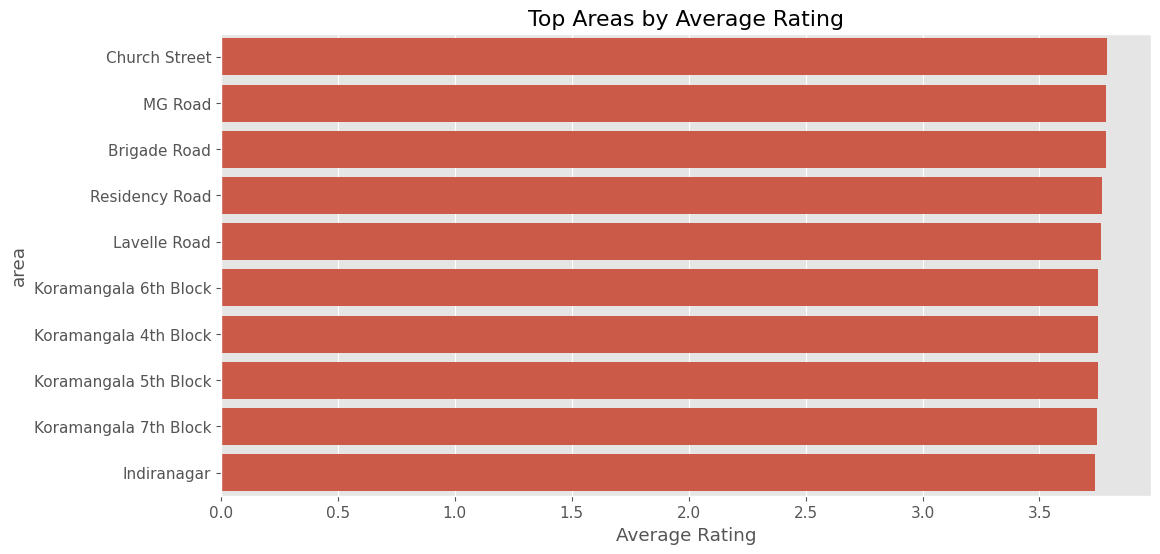

In [99]:
#Average Rating by Area
area_rating = (
    df_clean
    .groupby('area')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=area_rating.values,
    y=area_rating.index
)

plt.title('Top Areas by Average Rating')

plt.xlabel('Average Rating')

plt.show()

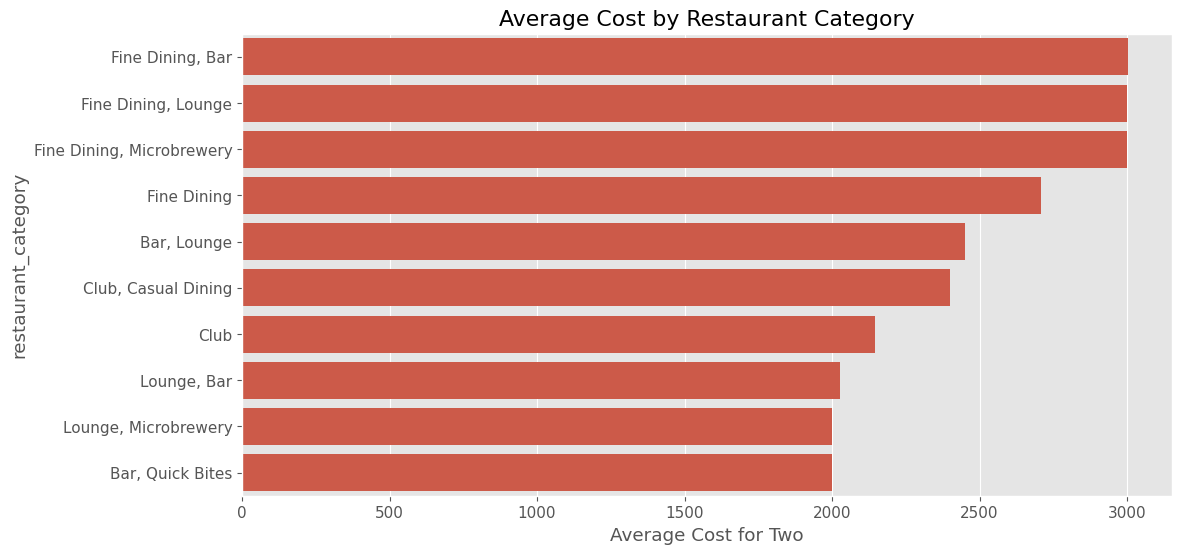

In [100]:
#Average Cost by Restaurant Category
category_cost = (
    df_clean
    .groupby('restaurant_category')['cost_for_two']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_cost.values,
    y=category_cost.index
)

plt.title('Average Cost by Restaurant Category')

plt.xlabel('Average Cost for Two')

plt.show()

In [101]:
top_votes = (
    df_clean.groupby('restaurant_name', as_index=False)['votes']
    .max()
    .sort_values(by='votes', ascending=False)
    .head(10)
)

print(top_votes)

                  restaurant_name  votes
1274  Byg Brewski Brewing Company  16832
8231                         Toit  14956
8269                     Truffles  14726
129     AB's - Absolute Barbecues  12121
7751              The Black Pearl  10550
978                   Big Pitcher   9300
5549                       Onesta   9085
548         Arbor Brewing Company   8419
2446            Empire Restaurant   8304
5907               Prost Brew Pub   7871
